# L01 · Exploring a Biomedical Dataset

*Companion notebook for Lecture 1 — Machine Learning for Biology and Medicine (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**
1. Load a biomedical dataset into the course's data layout: $\mathbf X\in\mathbb R^{n\times d}$ (rows = samples), $\mathbf y$.
2. Explore it: class balance, feature scales, histograms and scatter plots by class.
3. Fit a first (very simple) model on training data and evaluate it on held-out patients.
4. Represent a DNA sequence as a one-hot matrix.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from course_utils import seed_everything, plot_style

seed_everything(0)
plot_style()

## 1. Dataset: breast-cancer biopsies (Wisconsin Diagnostic Breast Cancer)

- **What is measured:** a fine-needle aspirate (FNA) of a breast mass is imaged under a microscope; software outlines the cell nuclei and measures 10 properties (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension).
- **Features:** for each property, the mean, standard error and "worst" (mean of the three largest values) over the nuclei in the image → $d = 30$.
- **One sample:** one patient's biopsy. **Target:** malignant or benign.
- Source: Street, Wolberg & Mangasarian (1993); Wolberg et al., *Breast Cancer Wisconsin (Diagnostic)*, UCI Machine Learning Repository (1995), doi:10.24432/C5DW2B, license CC BY 4.0. Bundled with scikit-learn (no download).

scikit-learn codes benign as 1. We follow the course convention that the **positive class (y = 1) is malignant**.

In [2]:
data = load_breast_cancer()
X = data.data
y = 1 - data.target          # 1 = malignant, 0 = benign
names = list(data.feature_names)
n, d = X.shape
print(f"X has shape {X.shape}: n = {n} patients, d = {d} features")
print(f"malignant: {y.sum()}  benign: {(1 - y).sum()}  ({y.mean():.1%} malignant)")
print("missing values:", np.isnan(X).sum())

X has shape (569, 30): n = 569 patients, d = 30 features
malignant: 212  benign: 357  (37.3% malignant)
missing values: 0


## 2. Data exploration
Feature scales differ by orders of magnitude, which will matter for distance-based methods (Lecture 2) and gradient descent (Lecture 4).

In [3]:
df = pd.DataFrame(X, columns=names)
df.describe().T[["mean", "std", "min", "max"]].sort_values("mean").iloc[[0, 1, 2, -3, -2, -1]]

,mean,std,min,max
fractal dimension error,0.003795,0.002646,0.000895,0.02984
smoothness error,0.007041,0.003003,0.001713,0.03113
concave points error,0.011796,0.006170,0.000000,0.05279
worst perimeter,107.261213,33.602542,50.410000,251.20000
mean area,654.889104,351.914129,143.500000,2501.00000
worst area,880.583128,569.356993,185.200000,4254.00000


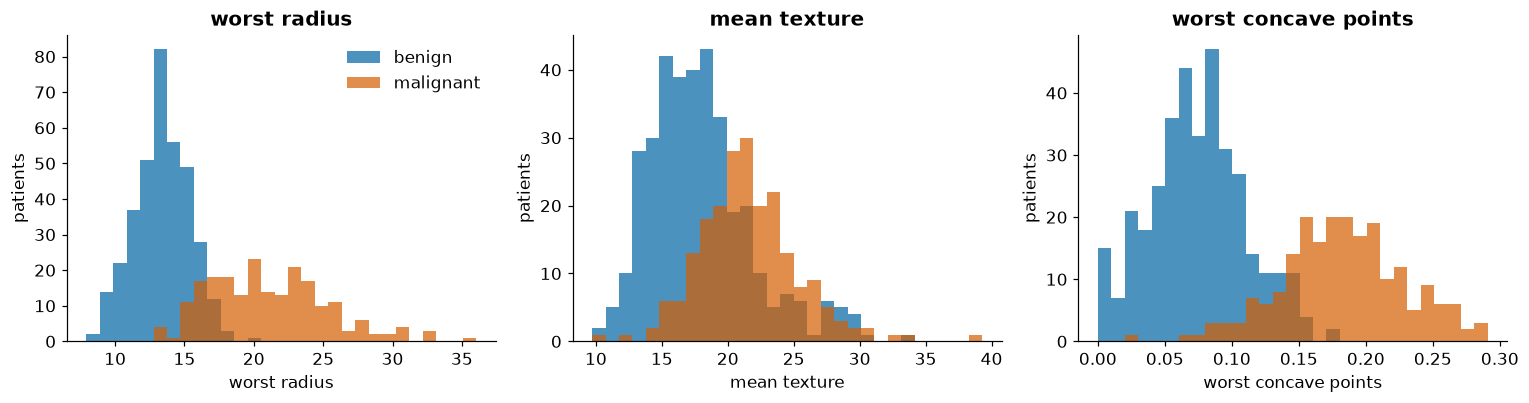

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, feat in zip(axes, ["worst radius", "mean texture", "worst concave points"]):
    j = names.index(feat)
    bins = np.linspace(X[:, j].min(), X[:, j].max(), 30)
    ax.hist(X[y == 0, j], bins=bins, alpha=0.7, label="benign")
    ax.hist(X[y == 1, j], bins=bins, alpha=0.7, label="malignant", color="#D55E00")
    ax.set(title=feat, xlabel=feat, ylabel="patients")
axes[0].legend(); plt.tight_layout(); plt.show()

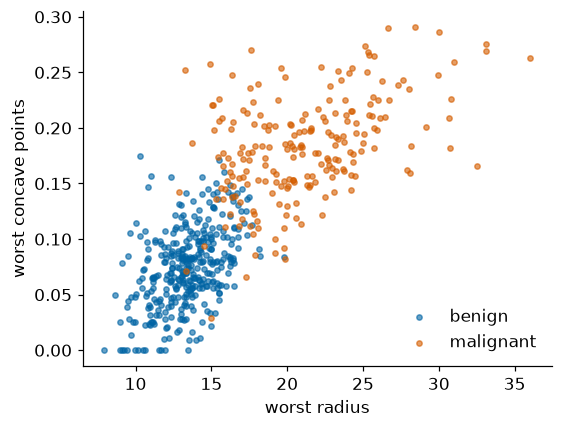

In [5]:
a, b = names.index("worst radius"), names.index("worst concave points")
plt.figure(figsize=(5.5, 4.2))
plt.scatter(X[y == 0, a], X[y == 0, b], s=12, alpha=0.6, label="benign")
plt.scatter(X[y == 1, a], X[y == 1, b], s=12, alpha=0.6, label="malignant", color="#D55E00")
plt.xlabel("worst radius"); plt.ylabel("worst concave points"); plt.legend(); plt.show()

Which single feature separates the classes best? A quick screen: for each feature, the difference in class means divided by the pooled standard deviation.

In [6]:
def separation(x, y):
    m0, m1 = x[y == 0].mean(), x[y == 1].mean()
    s = np.sqrt((x[y == 0].var() + x[y == 1].var()) / 2)
    return abs(m1 - m0) / s

scores = pd.Series({f: separation(X[:, j], y) for j, f in enumerate(names)}).sort_values(ascending=False)
scores.head(8).round(2)

worst concave points    2.61
worst perimeter         2.38
mean concave points     2.33
worst radius            2.33
mean perimeter          2.13
mean radius             2.06
worst area              1.97
mean concavity          1.88
dtype: float64

**Careful:** we just used *all* patients to rank features. That is fine for exploration, but if we used this ranking to build a model and then evaluated on the same patients, the evaluation would be biased (Lecture 6).

## 3. A first model: a threshold on one feature
Rule: predict malignant if `worst radius > t`. We choose $t$ using **training** patients only.

best threshold on training data: t = 16.77
training accuracy = 0.922  (n_train = 398)
test accuracy     = 0.924  (n_test = 171)


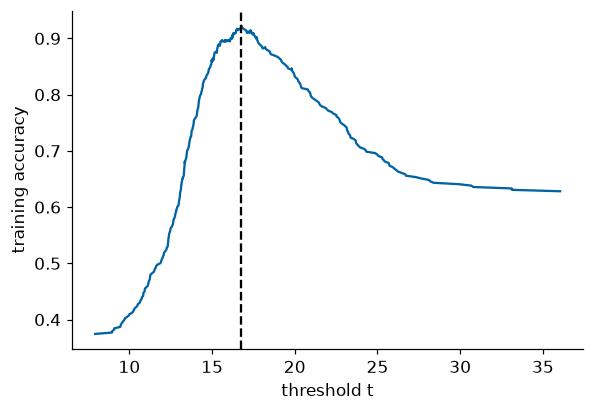

In [7]:
j = names.index("worst radius")
x_tr, x_te, y_tr, y_te = train_test_split(X[:, j], y, test_size=0.3, random_state=0, stratify=y)
candidates = np.sort(x_tr)
train_acc = np.array([np.mean((x_tr > t) == y_tr) for t in candidates])
t_best = candidates[train_acc.argmax()]
print(f"best threshold on training data: t = {t_best:.2f}")
print(f"training accuracy = {train_acc.max():.3f}  (n_train = {len(y_tr)})")
print(f"test accuracy     = {np.mean((x_te > t_best) == y_te):.3f}  (n_test = {len(y_te)})")

plt.plot(candidates, train_acc)
plt.axvline(t_best, color="k", ls="--")
plt.xlabel("threshold t"); plt.ylabel("training accuracy"); plt.show()

The threshold was chosen to maximize training accuracy, so training accuracy is (slightly) optimistic. The held-out test patients estimate how the rule would do on new patients.

How much does the test estimate depend on which patients happened to land in the test set?

In [8]:
test_accs = []
for seed in range(50):
    x_tr, x_te, y_tr, y_te = train_test_split(X[:, j], y, test_size=0.3, random_state=seed, stratify=y)
    c = np.sort(x_tr)
    t = c[np.argmax([np.mean((x_tr > t) == y_tr) for t in c])]
    test_accs.append(np.mean((x_te > t) == y_te))
print(f"test accuracy over 50 random splits: mean {np.mean(test_accs):.3f}, range {min(test_accs):.3f}–{max(test_accs):.3f}")

test accuracy over 50 random splits: mean 0.919, range 0.895–0.965


## 4. Representing a DNA sequence
A model needs numbers. For DNA we use a **one-hot** matrix $\mathbf X\in\{0,1\}^{L\times 4}$: one row per position, one column per base (A, C, G, T).

In [9]:
ALPHABET = "ACGT"

def one_hot(seq):
    X = np.zeros((len(seq), 4), dtype=int)
    for t, base in enumerate(seq):
        X[t, ALPHABET.index(base)] = 1
    return X

print(one_hot("ACGTA"))

[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]
 [1 0 0 0]]


## 5. Biological interpretation
- Malignant nuclei are larger (radius, area) and have more irregular boundaries (concavity, concave points): pathologists use the same cues.
- The classes overlap, so no single threshold is perfect. Later lectures combine all 30 features (kNN, logistic regression, neural networks).
- This dataset comes from one institution. Performance on biopsies processed elsewhere could differ (dataset shift, Lecture 6).

## 6. Try it yourself
1. Pick a different feature. Which single feature separates best? (Change `"worst radius"` in the threshold-rule cell; compare with the separation scores above.)
2. Change the random split seed. How much does test accuracy move? (Edit `random_state=0` in the threshold-rule cell; the 50-split loop above gives the answer in one go.)
3. Encode `GATTACA` and check the matrix shape. What does the sum of each column tell you?
4. What accuracy does "always predict benign" achieve? Why is accuracy a weak metric here?
5. *(CS284A)* The threshold rule has one parameter. Why can its training accuracy still be optimistic?